In [1]:


!pip install scikit-learn==0.23.1



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 62.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import preprocessing
%matplotlib inline



In [3]:
!wget -O teleCust1000t.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv

--2025-11-28 13:59:31--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 36047 (35K) [text/csv]
Saving to: ‘teleCust1000t.csv’

teleCust1000t.csv   100%[===================>]  35.20K  --.-KB/s    in 0.001s  

2025-11-28 13:59:32 (25.6 MB/s) - ‘teleCust1000t.csv’ saved [36047/36047]



In [4]:


df = pd.read_csv('teleCust1000t.csv')
df.head()



,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


In [5]:


df['custcat'].value_counts()



,count
custcat,
3,281
1,266
4,236
2,217


array([[<Axes: title={'center': 'income'}>]], dtype=object)

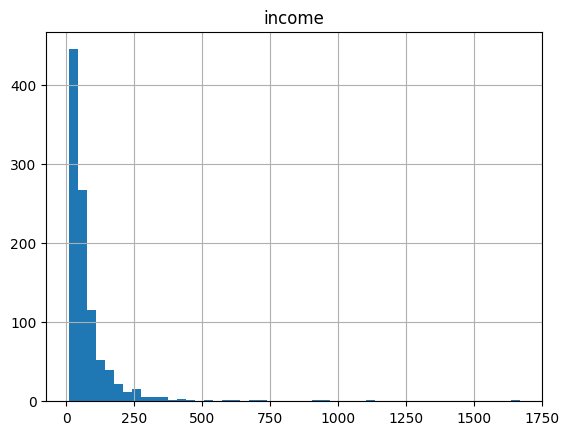

In [6]:


df.hist(column='income', bins=50)



In [7]:


df.columns



Index(['region', 'tenure', 'age', 'marital', 'address', 'income', 'ed',
       'employ', 'retire', 'gender', 'reside', 'custcat'],
      dtype='object')

In [8]:


X = df[['region', 'tenure','age', 'marital', 'address', 'income', 'ed', 'employ','retire', 'gender', 'reside']] .values  #.astype(float)
X[0:5]



array([[  2.,  13.,  44.,   1.,   9.,  64.,   4.,   5.,   0.,   0.,   2.],
       [  3.,  11.,  33.,   1.,   7., 136.,   5.,   5.,   0.,   0.,   6.],
       [  3.,  68.,  52.,   1.,  24., 116.,   1.,  29.,   0.,   1.,   2.],
       [  2.,  33.,  33.,   0.,  12.,  33.,   2.,   0.,   0.,   1.,   1.],
       [  2.,  23.,  30.,   1.,   9.,  30.,   1.,   2.,   0.,   0.,   4.]])

In [9]:


y = df['custcat'].values
y[0:5]



array([1, 4, 3, 1, 3])

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (800, 11) (800,)
Test set: (200, 11) (200,)


In [11]:


from sklearn.neighbors import KNeighborsClassifier



In [12]:
k = 4
#Train Model and Predict
neigh = KNeighborsClassifier(n_neighbors = k).fit(X_train,y_train)
neigh

KNeighborsClassifier(n_neighbors=4)

In [13]:


yhat = neigh.predict(X_test)
yhat[0:5]



array([3, 1, 3, 4, 4])

In [ ]:
from sklearn import metrics
print("Train set Accuracy: ", metrics.accuracy_score(y_train, neigh.predict(X_train)))
print("Test set Accuracy: ", metrics.accuracy_score(y_test, yhat))

Train set Accuracy:  0.55875
Test set Accuracy:  0.26


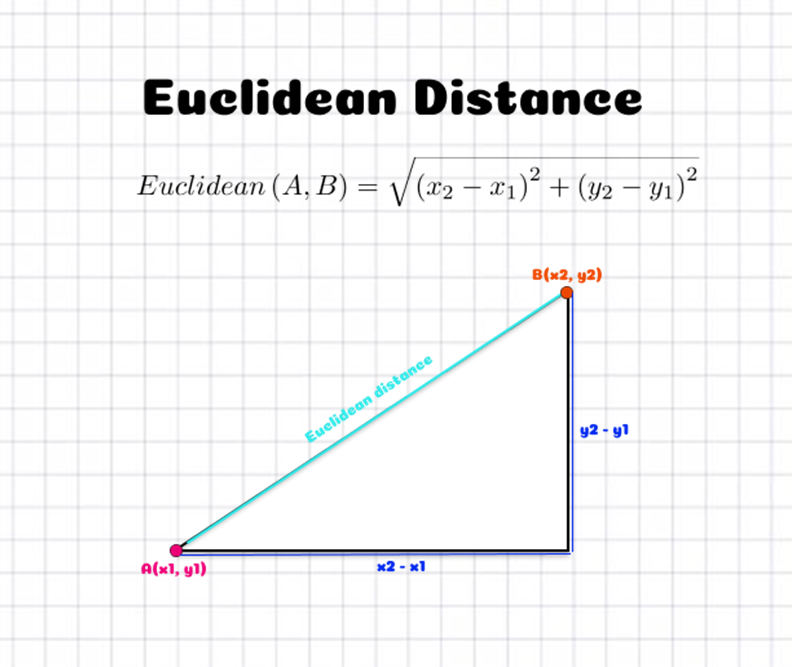![Euclidean-distance.png]()

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

2. Creating Dataset

In [2]:
X, y = make_blobs(n_samples = 500, n_features = 2, centers = 4,cluster_std = 1.5, random_state = 4)

#make_blobs creates a synthetic dataset for classification.
#n_samples=500 → creates 500 data points
#n_features=2 → each point has 2 features (X is 500×2)
#centers=4 → data will form 4 clusters (labels 0–3)
#cluster_std=1.5 → controls how spread-out each cluster is
#random_state=4 → makes the generated data reproducible

3. Visualize the Dataset

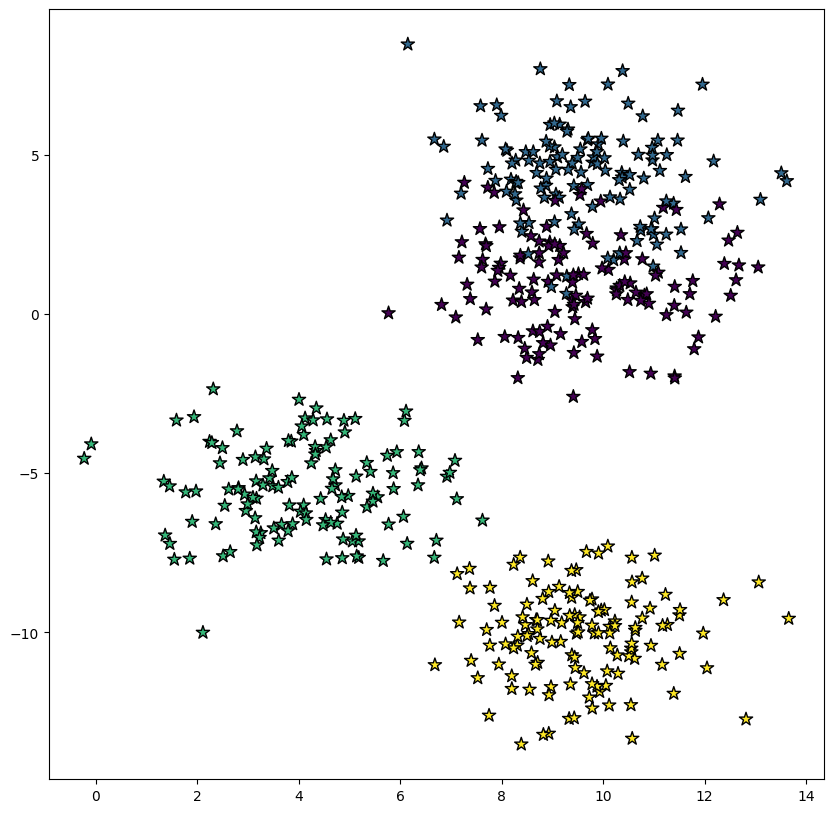

In [4]:
#plt.style.use('seaborn')
plt.figure(figsize = (10,10))
plt.scatter(X[:,0], X[:,1], c=y, marker= '*',s=100,edgecolors='black')
plt.show()

4. Splitting Data into Training and Testing Datasets

It is critical to partition a dataset into train and test sets for every supervised machine learning method. We first train the model and then put it to the test on various portions of the dataset. If we don’t separate the data, we’re simply testing the model with data it already knows. Using the train_test_split method, we can simply separate the tests.


With the train size and test size options, we may determine how much of the original data is utilized for train and test sets, respectively. The default separation is 75% for the train set and 25% for the test set.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

5. KNN Classifier Implementation

* After that, we’ll build a kNN classifier object. I develop two classifiers with k values of 1 and 5 to demonstrate the relevance of the k value. The models are then trained using a train set. The k value is chosen using the n_neighbors argument. It does not need to be explicitly specified because the default value is 5.



In [6]:
knn5 = KNeighborsClassifier(n_neighbors = 5)
knn1 = KNeighborsClassifier(n_neighbors=1)

6. Predictions for the KNN Classifiers

In [7]:
knn5.fit(X_train, y_train)
knn1.fit(X_train, y_train)

y_pred_5 = knn5.predict(X_test)
y_pred_1 = knn1.predict(X_test)

7. Predict Accuracy for both k values

In [9]:
from sklearn.metrics import accuracy_score
print("Accuracy with k=5", accuracy_score(y_test, y_pred_5)*100)
print("Accuracy with k=1", accuracy_score(y_test, y_pred_1)*100)

Accuracy with k=5 93.60000000000001
Accuracy with k=1 90.4


8. Visualize Predictions

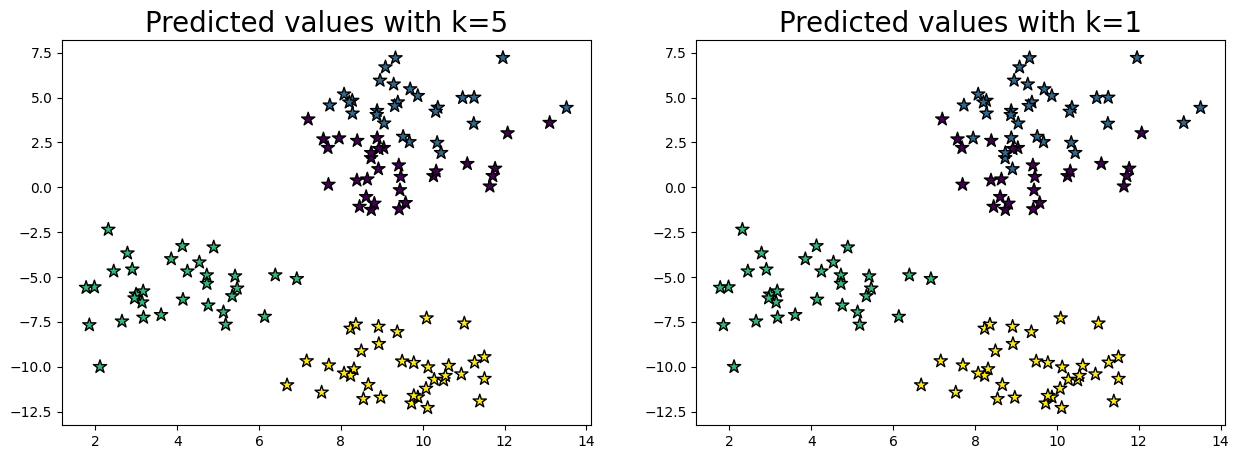

In [10]:
plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_5, marker= '*', s=100,edgecolors='black')
plt.title("Predicted values with k=5", fontsize=20)

plt.subplot(1,2,2)
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_1, marker= '*', s=100,edgecolors='black')
plt.title("Predicted values with k=1", fontsize=20)
plt.show()


How to find the best k value to implement KNN
  * k=1: The model is too narrow and not properly generalized. It also has a high sensitivity to noise. The model predicts new, previously unknown data points with a high degree of accuracy on a train set, but it is a poor predictor on fresh, previously unseen data points. As a result, we’re likely to have an overfit model.
  * k=100: The model is overly broad and unreliable on both the train and test sets. Underfitting is the term for this circumstance.




Limitations of KNN Algorithm

KNN is a straightforward algorithm to grasp. It does not rely on any internal machine learning model to generate predictions. KNN is a classification method that simply needs to know how many categories there are to work (one or more). This means it can quickly assess whether or not a new category should be added without having to know how many others there are.

The drawback of this simplicity is that it can’t anticipate unusual things (like new diseases), which KNN can’t accomplish since it doesn’t know what the prevalence of a rare item would be in a healthy population.

Although KNN achieves high accuracy on the testing set, it is slower and more expensive in terms of time and memory. It needs a considerable amount of memory in order to store the whole training dataset for prediction. Furthermore, because Euclidean distance is very sensitive to magnitudes, characteristics in the dataset with large magnitudes will always outweigh those with small magnitudes.

Finally, considering all we’ve discussed so far, we should keep in mind that KNN isn’t ideal for large-dimensional datasets.
